In [1]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f' file uploaded "{fn}" with length {len(uploaded[fn])} bytes')


Saving Womens Clothing E-Commerce Reviews.csv to Womens Clothing E-Commerce Reviews.csv
 file uploaded "Womens Clothing E-Commerce Reviews.csv" with length 8483448 bytes


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


In [7]:
df = pd.read_csv('Womens Clothing E-Commerce Reviews.csv')

print("Dataset loaded!")
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

Dataset loaded!
Shape: (23486, 11)

Columns:
 ['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']


In [8]:
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [10]:
df.describe()

,Unnamed: 0,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,11742.500000,918.118709,43.198544,4.196032,0.822362,2.535936
std,6779.968547,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,0.000000,18.000000,1.000000,0.000000,0.000000
25%,5871.250000,861.000000,34.000000,4.000000,1.000000,0.000000
50%,11742.500000,936.000000,41.000000,5.000000,1.000000,1.000000
75%,17613.750000,1078.000000,52.000000,5.000000,1.000000,3.000000
max,23485.000000,1205.000000,99.000000,5.000000,1.000000,122.000000


Missing values:

                 Missing Count  Missing %
Title                     3810  16.222430
Review Text                845   3.597888
Division Name               14   0.059610
Department Name             14   0.059610
Class Name                  14   0.059610


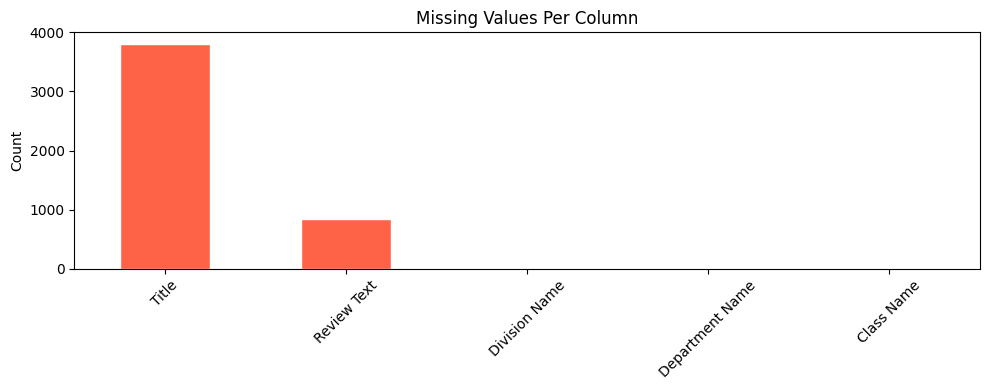

In [13]:
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

print("Missing values:\n")
print(missing_df[missing_df['Missing Count'] > 0])

# Visualize
plt.figure(figsize=(10, 4))
missing[missing > 0].plot(kind='bar', color='tomato', edgecolor='white')
plt.title('Missing Values Per Column')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# Drop rows where these critical columns are missing
df = df.dropna(subset=['Review Text', 'Division Name',
                        'Department Name', 'Class Name'])

# Drop unnamed index column if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Reset index
df = df.reset_index(drop=True)

print("After cleaning:")
print("Shape:", df.shape)

After cleaning:
Shape: (22628, 10)


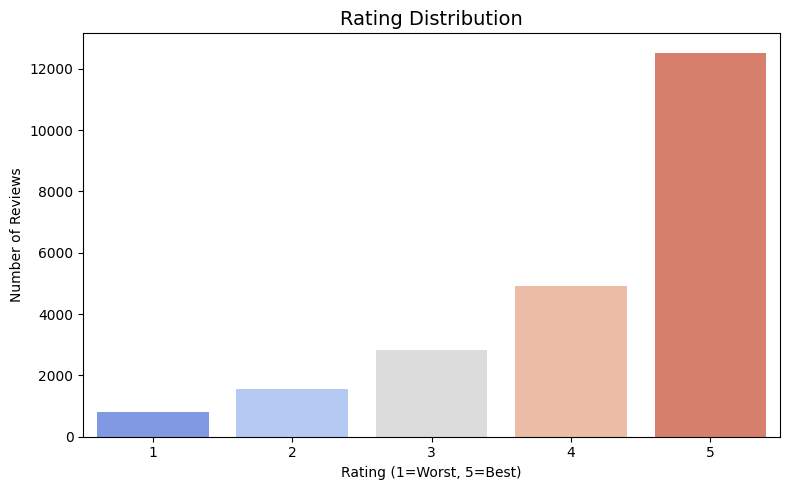

Rating breakdown:
Rating
1      821
2     1549
3     2823
4     4908
5    12527
Name: count, dtype: int64


In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Rating', data=df, palette='coolwarm')
plt.title('Rating Distribution', fontsize=14)
plt.xlabel('Rating (1=Worst, 5=Best)')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

print("Rating breakdown:")
print(df['Rating'].value_counts().sort_index())

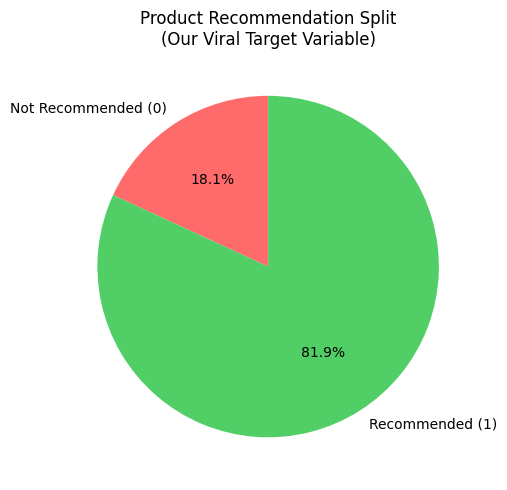


Recommendation counts:
Recommended IND
0     4101
1    18527
Name: count, dtype: int64


In [16]:
plt.figure(figsize=(6, 5))
labels = ['Not Recommended (0)', 'Recommended (1)']
sizes = df['Recommended IND'].value_counts().sort_index()
colors = ['#ff6b6b', '#51cf66']

plt.pie(sizes, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90)
plt.title('Product Recommendation Split\n(Our Viral Target Variable)')
plt.tight_layout()
plt.show()

print("\nRecommendation counts:")
print(sizes)

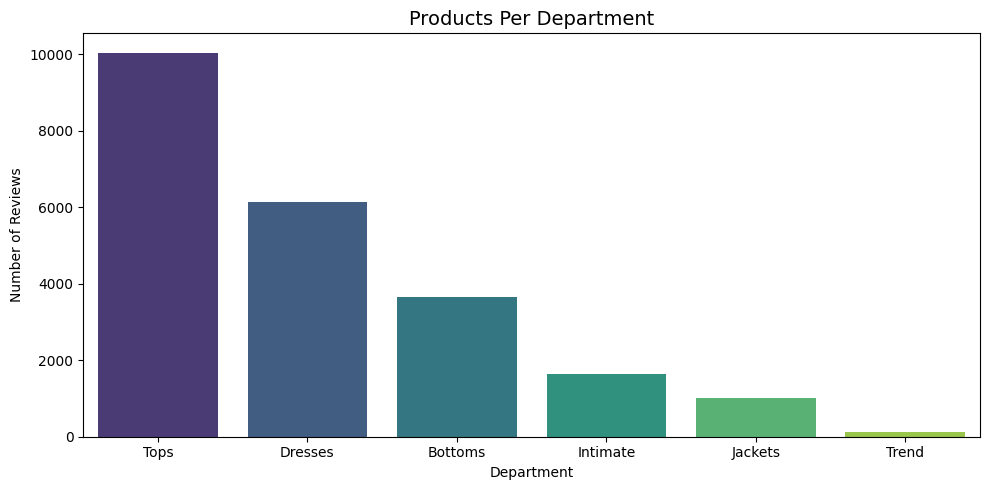

In [17]:
plt.figure(figsize=(10, 5))
dept_counts = df['Department Name'].value_counts()
sns.barplot(x=dept_counts.index, y=dept_counts.values, palette='viridis')
plt.title('Products Per Department', fontsize=14)
plt.xlabel('Department')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

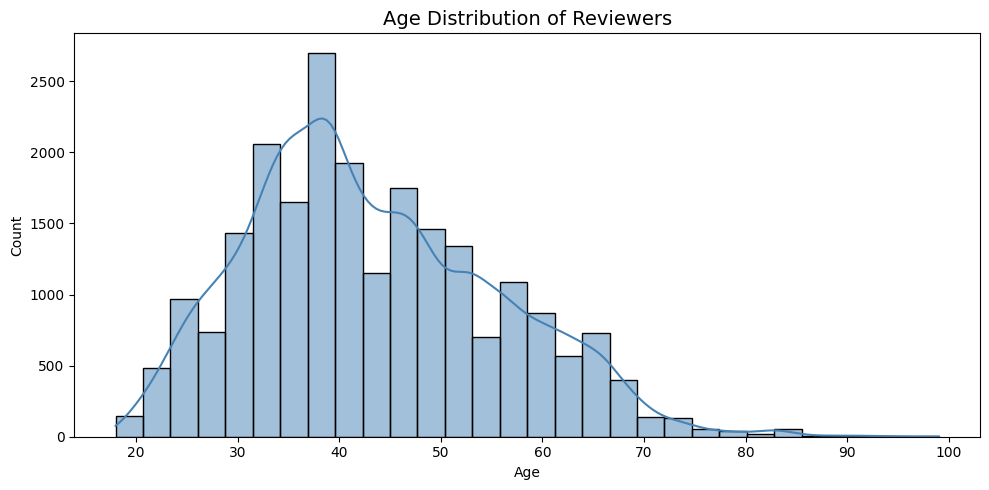

Average age: 43.3
Most common age: 39


In [18]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'], bins=30, color='steelblue', kde=True)
plt.title('Age Distribution of Reviewers', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("Average age:", round(df['Age'].mean(), 1))
print("Most common age:", df['Age'].mode()[0])

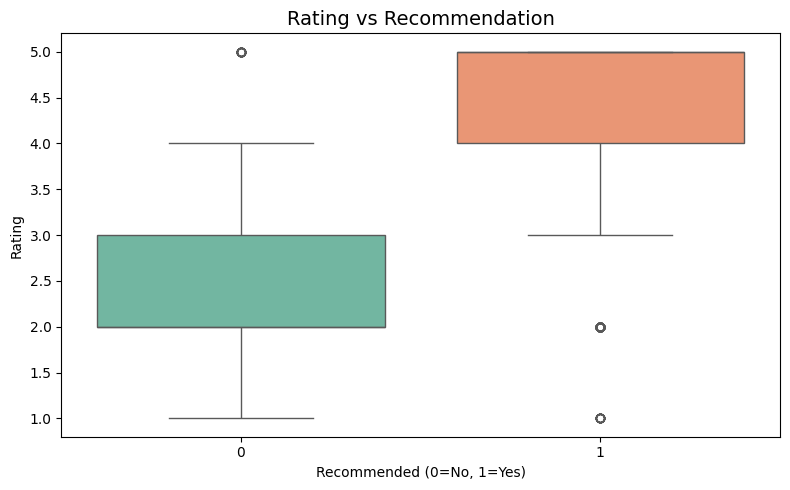

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Recommended IND', y='Rating',
            data=df, palette='Set2')
plt.title('Rating vs Recommendation', fontsize=14)
plt.xlabel('Recommended (0=No, 1=Yes)')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

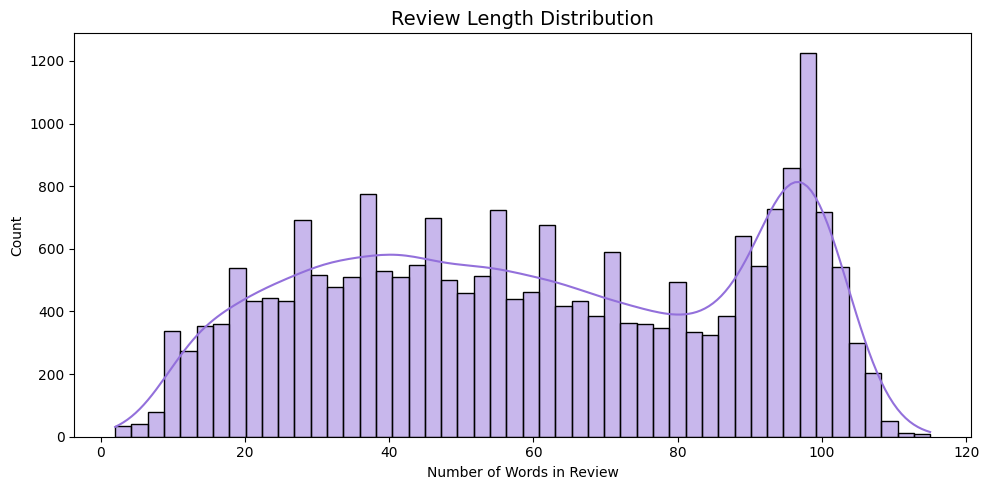

Average review length: 60 words


In [20]:
# Create review length column
df['review_length'] = df['Review Text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(df['review_length'], bins=50, color='mediumpurple', kde=True)
plt.title('Review Length Distribution', fontsize=14)
plt.xlabel('Number of Words in Review')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("Average review length:", round(df['review_length'].mean()), "words")

In [21]:
print("=" * 45)
print("      TRENDLENS — EDA KEY INSIGHTS")
print("=" * 45)
print(f"Total Reviews         : {len(df)}")
print(f"Total Departments     : {df['Department Name'].nunique()}")
print(f"Average Rating        : {round(df['Rating'].mean(), 2)}")
print(f"Viral Products (%)    : {round(df['Recommended IND'].mean()*100, 1)}%")
print(f"Average Reviewer Age  : {round(df['Age'].mean(), 1)}")
print(f"Avg Review Length     : {round(df['review_length'].mean())} words")
print("=" * 45)

      TRENDLENS — EDA KEY INSIGHTS
Total Reviews         : 22628
Total Departments     : 6
Average Rating        : 4.18
Viral Products (%)    : 81.9%
Average Reviewer Age  : 43.3
Avg Review Length     : 60 words


In [24]:
BASE = '' # Define BASE, assuming current directory for now
save_path = BASE + 'clean_data.csv'
df.to_csv(save_path, index=False)

print(f"Clean data saved!")
print(f"Shape: {df.shape}")
print(f"Path: {save_path}")

Clean data saved!
Shape: (22628, 11)
Path: clean_data.csv


In [25]:
print(df.columns.tolist())
print(df.shape)

['Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name', 'review_length']
(22628, 11)


In [26]:
from google.colab import files
files.download('clean_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>